In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/aisehack-2-0/sample_submission.csv
/kaggle/input/competitions/aisehack-2-0/base_line_model.ipynb
/kaggle/input/competitions/aisehack-2-0/train.csv
/kaggle/input/competitions/aisehack-2-0/test.csv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 52.0 MB/s eta 0:00:00
Loading data...
Extracting molecular features (this may take a minute)...
Training LightGBM model for Tg...
Training LightGBM model for Egc...

--- Model Performance ---
Tg OOF R2:  0.8850
Egc OOF R2: 0.8929
Mean CV R2: 0.8889

Success: 'submission.csv' generated and ready for scoring.


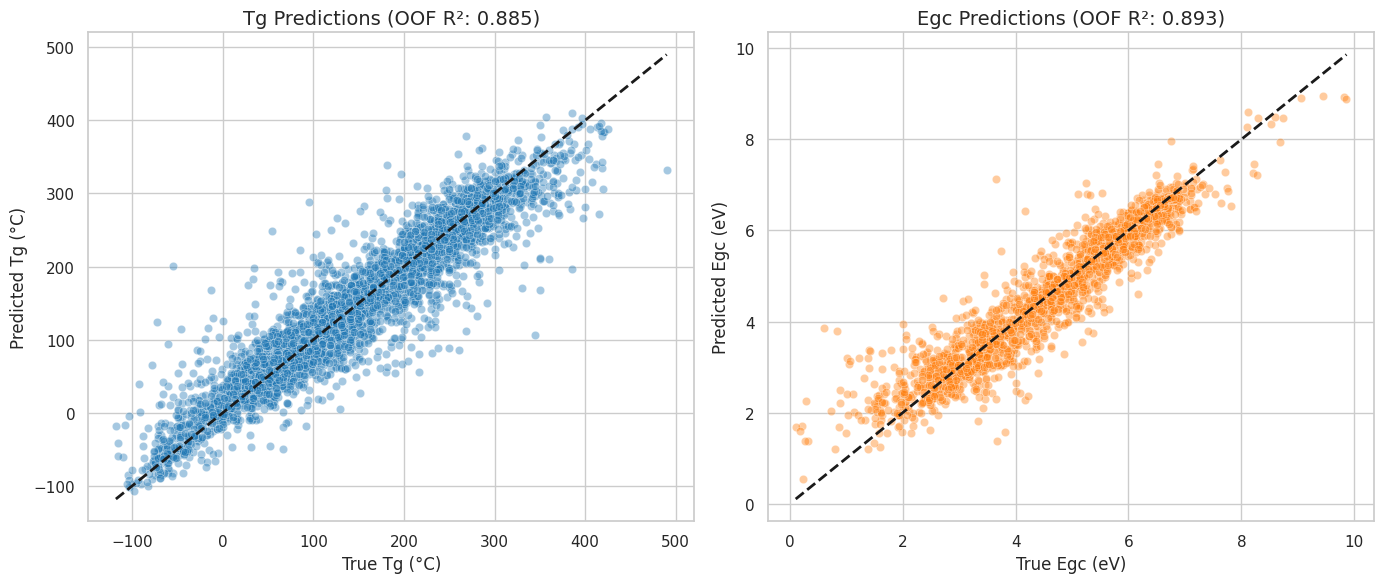

In [2]:
!pip install rdkit -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit import RDLogger
import warnings

# --- 0. Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Disable RDKit C++ level warnings
RDLogger.DisableLog('rdApp.*') 

# --- 1. Load Data ---
print("Loading data...")
data_dir = '/kaggle/input/competitions/aisehack-2-0/'
train = pd.read_csv(data_dir + 'train.csv')
test = pd.read_csv(data_dir + 'test.csv')

# Split by target type
train_tg = train[train['target_type'] == 'tg'].reset_index(drop=True)
train_egc = train[train['target_type'] == 'egc'].reset_index(drop=True)

test_tg = test[test['target_type'] == 'tg'].reset_index(drop=True)
test_egc = test[test['target_type'] == 'egc'].reset_index(drop=True)

# --- 2. Feature Engineering ---
def extract_features(smiles_series, n_bits=2048):
    features = []
    
    # Use the new, non-deprecated MorganGenerator
    mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            # Generate fingerprints using the modern generator
            morgan = list(mfp_gen.GetFingerprint(mol))
            maccs = list(MACCSkeys.GenMACCSKeys(mol))
            features.append(morgan + maccs)
        else:
            # Handle invalid SMILES securely with zero-padding
            features.append([0] * (n_bits + 167))
    return np.array(features)

print("Extracting molecular features (this may take a minute)...")
X_train_tg = extract_features(train_tg['smiles'])
y_train_tg = train_tg['target'].values
X_test_tg = extract_features(test_tg['smiles'])

X_train_egc = extract_features(train_egc['smiles'])
y_train_egc = train_egc['target'].values
X_test_egc = extract_features(test_egc['smiles'])

# --- 3. Modeling ---
def train_evaluate(X, y, X_test, params, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    preds = np.zeros(len(X_test))
    
    for trn_idx, val_idx in kf.split(X):
        X_trn, y_trn = X[trn_idx], y[trn_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_trn, y_trn, 
                  eval_set=[(X_val, y_val)], 
                  callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        
        oof[val_idx] = model.predict(X_val)
        preds += model.predict(X_test) / n_splits
        
    score = r2_score(y, oof)
    return oof, preds, score

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'n_estimators': 800,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print("Training LightGBM model for Tg...")
oof_tg, preds_tg, r2_tg = train_evaluate(X_train_tg, y_train_tg, X_test_tg, lgb_params)

print("Training LightGBM model for Egc...")
oof_egc, preds_egc, r2_egc = train_evaluate(X_train_egc, y_train_egc, X_test_egc, lgb_params)

print("\n--- Model Performance ---")
print(f"Tg OOF R2:  {r2_tg:.4f}")
print(f"Egc OOF R2: {r2_egc:.4f}")
print(f"Mean CV R2: {(r2_tg + r2_egc) / 2:.4f}")

# --- 4. Submission ---
test_tg['target'] = preds_tg
test_egc['target'] = preds_egc

# Recombine and match the original test ID order
test_preds = pd.concat([test_tg, test_egc])
submission = test[['id']].merge(test_preds[['id', 'target']], on='id', how='left')

submission.to_csv('submission.csv', index=False)
print("\nSuccess: 'submission.csv' generated and ready for scoring.")

# --- 5. Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=y_train_tg, y=oof_tg, ax=axes[0], alpha=0.4, color='#1f77b4')
axes[0].plot([y_train_tg.min(), y_train_tg.max()], [y_train_tg.min(), y_train_tg.max()], 'k--', lw=2)
axes[0].set_title(f"Tg Predictions (OOF R²: {r2_tg:.3f})", fontsize=14)
axes[0].set_xlabel("True Tg (°C)")
axes[0].set_ylabel("Predicted Tg (°C)")

sns.scatterplot(x=y_train_egc, y=oof_egc, ax=axes[1], alpha=0.4, color='#ff7f0e')
axes[1].plot([y_train_egc.min(), y_train_egc.max()], [y_train_egc.min(), y_train_egc.max()], 'k--', lw=2)
axes[1].set_title(f"Egc Predictions (OOF R²: {r2_egc:.3f})", fontsize=14)
axes[1].set_xlabel("True Egc (eV)")
axes[1].set_ylabel("Predicted Egc (eV)")

plt.tight_layout()
plt.show()